# KNN

## Importar Dados

In [2]:
import pandas as pd
caminho = '../'

X_test = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv')
y_train = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv')

## KNN - Default

In [3]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

c:\Users\renan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===

Acurácia: 0.7838
Precisão: 0.7551
Recall: 0.7389
F1-Score: 0.7456
MCC: 0.4938
AUC: 0.8352
--------------------------------------------------


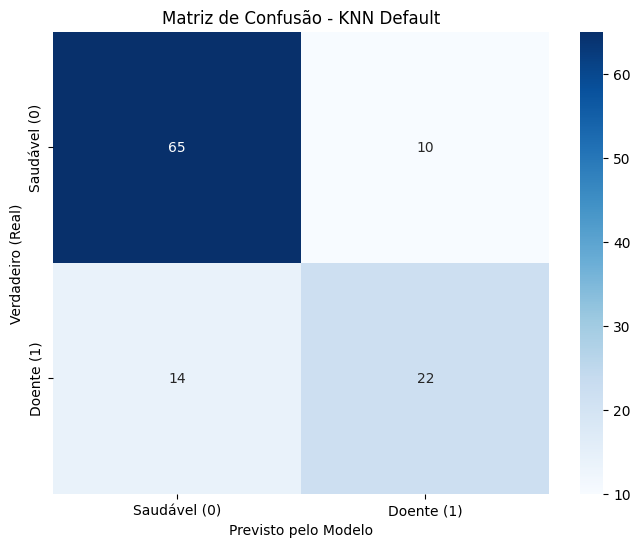

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)

# Fazendo as Previsões no conjunto de teste
y_pred_def = knn.predict(X_test)
y_prob_def = knn.predict_proba(X_test)[:, 1]

# Métricas
acuracia_def = accuracy_score(y_test, y_pred_def)
precisao_def = precision_score(y_test, y_pred_def, average='macro', zero_division=0)
recall_def = recall_score(y_test, y_pred_def, average='macro', zero_division=0)
f1_def = f1_score(y_test, y_pred_def, average='macro', zero_division=0)
mcc_def = matthews_corrcoef(y_test, y_pred_def)
auc = roc_auc_score(y_test, y_prob_def)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO (KNN DEFAULT) ===\n")
print(f"Acurácia: {acuracia_def:.4f}")
print(f"Precisão: {precisao_def:.4f}")
print(f"Recall: {recall_def:.4f}")
print(f"F1-Score: {f1_def:.4f}")
print(f"MCC: {mcc_def:.4f}")
print(f"AUC: {auc:.4f}")
print("-" * 50)

# Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_def)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])
plt.title('Matriz de Confusão - KNN Default')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## KNN - Melhorado

In [15]:
import optuna
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 10)
    }

    clf = KNeighborsClassifier(**params, n_jobs=-1)

    # Validação cruzada com F1-macro para avaliar o desempenho
    score = cross_val_score(clf, X_train, y_train.values.ravel(), scoring='accuracy', cv=5, n_jobs=-1).mean()
    return score

# Criando e executando o estudo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Melhor pontuação (CV): {study.best_value:.4f}")
print("Melhores parâmetros:")
print(study.best_params)

# Treinando o modelo final com os melhores parâmetros encontrados
best_knn = KNeighborsClassifier(**study.best_params, n_jobs=-1)
best_knn.fit(X_train, y_train.values.ravel())

[I 2026-08-14 17:10:26,373] A new study created in memory with name: no-name-6dbef5a7-94c8-436e-8f86-0d8d96754220
Best trial: 3. Best value: 0.817873:  13%|█▎        | 4/30 [00:00<00:00, 26.35it/s]

[I 2026-08-14 17:10:26,416] Trial 0 finished with value: 0.7790346907993968 and parameters: {'n_neighbors': 3, 'weights': 'uniform', 'p': 9}. Best is trial 0 with value: 0.7790346907993968.
[I 2026-08-14 17:10:26,458] Trial 1 finished with value: 0.8021116138763198 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'p': 10}. Best is trial 1 with value: 0.8021116138763198.
[I 2026-08-14 17:10:26,486] Trial 2 finished with value: 0.7711161387631975 and parameters: {'n_neighbors': 2, 'weights': 'distance', 'p': 5}. Best is trial 1 with value: 0.8021116138763198.
[I 2026-08-14 17:10:26,518] Trial 3 finished with value: 0.8178733031674208 and parameters: {'n_neighbors': 19, 'weights': 'distance', 'p': 2}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,561] Trial 4 finished with value: 0.7866515837104073 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 7}. Best is trial 3 with value: 0.8178733031674208.


Best trial: 3. Best value: 0.817873:  33%|███▎      | 10/30 [00:00<00:00, 26.34it/s]

[I 2026-08-14 17:10:26,601] Trial 5 finished with value: 0.7941930618401207 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 6}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,644] Trial 6 finished with value: 0.7985671191553545 and parameters: {'n_neighbors': 7, 'weights': 'distance', 'p': 7}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,687] Trial 7 finished with value: 0.7944193061840121 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'p': 8}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,715] Trial 8 finished with value: 0.8060331825037708 and parameters: {'n_neighbors': 21, 'weights': 'distance', 'p': 3}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,744] Trial 9 finished with value: 0.8023378582202112 and parameters: {'n_neighbors': 22, 'weights': 'uniform', 'p': 2}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,783] Trial 10 finish

Best trial: 3. Best value: 0.817873:  53%|█████▎    | 16/30 [00:00<00:00, 28.96it/s]

[I 2026-08-14 17:10:26,817] Trial 11 finished with value: 0.8023378582202112 and parameters: {'n_neighbors': 29, 'weights': 'uniform', 'p': 1}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,854] Trial 12 finished with value: 0.7748114630467573 and parameters: {'n_neighbors': 30, 'weights': 'uniform', 'p': 4}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,886] Trial 13 finished with value: 0.775339366515837 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,916] Trial 14 finished with value: 0.794343891402715 and parameters: {'n_neighbors': 26, 'weights': 'distance', 'p': 3}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,946] Trial 15 finished with value: 0.8139517345399698 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:26,976] Trial 16 fini

Best trial: 21. Best value: 0.825641:  73%|███████▎  | 22/30 [00:00<00:00, 27.28it/s]

[I 2026-08-14 17:10:27,008] Trial 17 finished with value: 0.8061085972850679 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 5}. Best is trial 3 with value: 0.8178733031674208.
[I 2026-08-14 17:10:27,052] Trial 18 finished with value: 0.8218702865761689 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 2}. Best is trial 18 with value: 0.8218702865761689.
[I 2026-08-14 17:10:27,106] Trial 19 finished with value: 0.8060331825037708 and parameters: {'n_neighbors': 23, 'weights': 'distance', 'p': 4}. Best is trial 18 with value: 0.8218702865761689.
[I 2026-08-14 17:10:27,139] Trial 20 finished with value: 0.8064102564102564 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 2}. Best is trial 18 with value: 0.8218702865761689.
[I 2026-08-14 17:10:27,174] Trial 21 finished with value: 0.8256410256410256 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8256410256410256.


Best trial: 21. Best value: 0.825641:  87%|████████▋ | 26/30 [00:00<00:00, 25.65it/s]

[I 2026-08-14 17:10:27,218] Trial 22 finished with value: 0.806184012066365 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 4}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,266] Trial 23 finished with value: 0.8218702865761689 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,309] Trial 24 finished with value: 0.8177978883861237 and parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 3}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,342] Trial 25 finished with value: 0.8062594268476622 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 1}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,373] Trial 26 finished with value: 0.8102564102564103 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8256410256410256.


Best trial: 21. Best value: 0.825641: 100%|██████████| 30/30 [00:01<00:00, 27.02it/s]


[I 2026-08-14 17:10:27,404] Trial 27 finished with value: 0.7791101055806937 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 4}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,435] Trial 28 finished with value: 0.8217194570135747 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 3}. Best is trial 21 with value: 0.8256410256410256.
[I 2026-08-14 17:10:27,484] Trial 29 finished with value: 0.8060331825037708 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 5}. Best is trial 21 with value: 0.8256410256410256.
Melhor pontuação (CV): 0.8256
Melhores parâmetros:
{'n_neighbors': 12, 'weights': 'distance', 'p': 2}


,n_neighbors,12
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,-1


In [16]:
fig = optuna.visualization.plot_param_importances(study)
fig.show()

fig = optuna.visualization.plot_optimization_history(study)
fig.show()

=== MÉTRICAS DE DESEMPENHO ===

Acurácia: 0.8288
Precisão: 0.8121
Recall:   0.7867
F1-Score: 0.7969
MCC:      0.5982
AUC:      0.8537
--------------------------------------------------


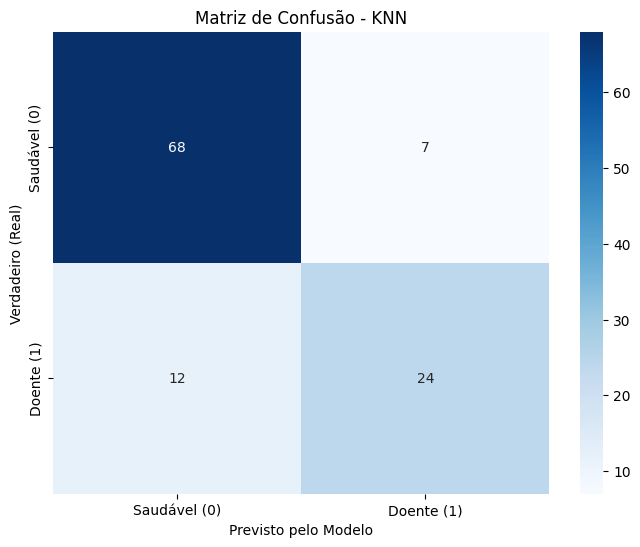

In [17]:
# Fazendo as Previsões
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)[:, 1]

# Métricas
acuracia_best = accuracy_score(y_test, y_pred_best)
precisao_best = precision_score(y_test, y_pred_best, average='macro')
recall_best   = recall_score(y_test, y_pred_best, average='macro')
f1_best       = f1_score(y_test, y_pred_best, average='macro')
mcc_best      = matthews_corrcoef(y_test, y_pred_best)

# O AUC binário recebe as classes reais e as probabilidades diretamente
auc = roc_auc_score(y_test, y_prob_best)

# Exibindo os Resultados
print("=== MÉTRICAS DE DESEMPENHO ===\n")
print(f"Acurácia: {acuracia_best:.4f}")
print(f"Precisão: {precisao_best:.4f}")
print(f"Recall:   {recall_best:.4f}")
print(f"F1-Score: {f1_best:.4f}")
print(f"MCC:      {mcc_best:.4f}")
print(f"AUC:      {auc:.4f}")
print("-" * 50)


# 5. Plotando a Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)

# Labels ajustados exclusivamente para as duas doenças
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável (0)', 'Doente (1)'],
            yticklabels=['Saudável (0)', 'Doente (1)'])

plt.title('Matriz de Confusão - KNN')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Verdadeiro (Real)')
plt.show()

## Salvar Resultados

In [18]:
import os
import pandas as pd

nome_modelo = 'knn'

# Caminhos dos arquivos
pasta_results = os.path.join(caminho, 'results')
os.makedirs(pasta_results, exist_ok=True)

arquivo_pred = os.path.join(pasta_results, 'predicoes.csv')
arquivo_proba = os.path.join(pasta_results, 'probabilidades.csv')

# Monta a linha com as predições de teste
linha_pred_teste = [nome_modelo, 'teste'] + list(y_pred_best)

# Salva adicionando no final do arquivo (mode='a')
pd.DataFrame([linha_pred_teste]).to_csv(
    arquivo_pred, mode='a', header=False, index=False
)

# Monta a linha com as probabilidades de teste 
probs = (
    y_prob_best[:, 1]
    if hasattr(y_prob_best, 'ndim') and y_prob_best.ndim == 2
    else y_prob_best
)
linha_proba_teste = [nome_modelo, 'teste'] + list(probs)

pd.DataFrame([linha_proba_teste]).to_csv(
    arquivo_proba, mode='a', header=False, index=False
)

print(f'Predições e probabilidades do modelo {nome_modelo} salvas com sucesso!')

Predições e probabilidades do modelo knn salvas com sucesso!
